# IEEE-14 FDI Attack Analysis

This notebook:

- Loads the IEEE-14 test network.
- Builds a deterministic DC state estimator (WLS).
- Adds Gaussian measurement noise.
- Injects three types of FDI attacks (basic, random, stealth).
- Compares residual-based detection (deterministic vs probabilistic SE).
- Motivates ML-based detection in SGSim for digital substations.

In [1]:
pip install pandapower

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import numpy as np
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import matplotlib.pyplot as plt
import pandapower.plotting.plotly as pplot
import seaborn as sns 

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

### 1 - Load IEEE-14 bus case

In [4]:
#Load IEEE-14 and run a power flow for an operating point
net = pn.case14()

# Run a power flow to get a steady-state solution 
# And these values act as the "true" system state for later estimation
pp.runpp(net, algorithm='nr', init='dc', calculate_voltage_angles=True)
print("Load flow converged:", net.converged)

Load flow converged: True


### 2 - Build deterministic DC state estimation model (WLS)

In [5]:
def build_dc_measurement_model(net):
    """
    Build a DC state estimation model using branch-flow measurements:

        z_k = (theta_i - theta_j) / x_ij

    Returns:
        H      : measurement matrix (m x n)
        x_true : true state vector (non-slack angles)
        z_true : true flow measurements (m,)
        mask   : boolean mask for non-slack buses
    """

    # ---------------------------
    # 1. Identify slack and true angles
    # ---------------------------
    slack_bus = net.ext_grid.bus.values[0]
    va_deg = net.res_bus.va_degree.values
    va_rad = np.deg2rad(va_deg)

    nb = len(net.bus)

    # Mask of non-slack buses
    mask = np.ones(nb, dtype=bool)
    mask[slack_bus] = False
    non_slack_buses = np.where(mask)[0]
    n = len(non_slack_buses)

    # True state vector (angles at non-slack buses)
    x_true = va_rad[mask]

    # ---------------------------
    # 2. Build measurement matrix H (branch flows)
    # ---------------------------
    rows = []
    z_true_list = []

    for _, line in net.line.iterrows():
        i = int(line.from_bus)
        j = int(line.to_bus)

        # Determine reactance x
        if 'x_ohm_per_km' in line.index:
            x = line.x_ohm_per_km * line.length_km
        elif 'x_ohm' in line.index:
            x = line.x_ohm
        elif 'x_pu' in line.index:
            x = line.x_pu
        elif 'x' in line.index:
            x = line.x
        else:
            raise ValueError("Could not determine reactance column.")

        row = np.zeros(n)

        # Only fill entries for non-slack buses
        if i in non_slack_buses:
            idx_i = np.where(non_slack_buses == i)[0][0]
            row[idx_i] =  1.0 / x

        if j in non_slack_buses:
            idx_j = np.where(non_slack_buses == j)[0][0]
            row[idx_j] = -1.0 / x

        rows.append(row)

        # True flow
        theta_i = va_rad[i]
        theta_j = va_rad[j]
        z_true_list.append((theta_i - theta_j) / x)

    H = np.vstack(rows)
    z_true = np.array(z_true_list)

    print("H shape =", H.shape)
    print("x_true shape =", x_true.shape)
    print("z_true shape =", z_true.shape)

    return H, x_true, z_true, mask


In [6]:
def simulate_measurements(H, x_true, sigma, rng):
    """
    Simulate noisy measurements z = H x_true + e,
    where e ~ N(0, sigma^2 I).
    """
    m = H.shape[0]
    noise = rng.normal(loc=0.0, scale=sigma, size=m)
    z = H @ x_true + noise
    return z


def wls_estimate(H, z, sigma, reg=1e-6):
    """
    Weighted least-squares state estimator with diagonal covariance R = sigma^2 I.

    Uses a regularised normal-equations solve to avoid singular-matrix issues:
        (Hᵀ R⁻¹ H + reg I) x = Hᵀ R⁻¹ z
    """
    m, n = H.shape
    R = (sigma ** 2) * np.eye(m)
    R_inv = np.linalg.inv(R)

    Ht_Rinv = H.T @ R_inv
    A = Ht_Rinv @ H
    b = Ht_Rinv @ z

    # Tikhonov regularisation to ensure A is invertible
    A_reg = A + reg * np.eye(n)

    x_hat = np.linalg.solve(A_reg, b)
    return x_hat, R



def compute_residuals(H, z, x_hat):
    """Residual vector r = z - H x_hat."""
    return z - H @ x_hat


def state_error(x_hat, x_true):
    """State estimation error vector."""
    return x_hat - x_true


In [7]:
net.line.columns

Index(['name', 'std_type', 'from_bus', 'to_bus', 'length_km', 'r_ohm_per_km',
       'x_ohm_per_km', 'c_nf_per_km', 'g_us_per_km', 'max_i_ka', 'df',
       'parallel', 'type', 'in_service', 'max_loading_percent', 'geo'],
      dtype='object')

### 3 - Generate Noisy Measurements

In [8]:
# Standard deviation of measurement noise
sigma = 0.04  # adjust if you want more/less noise

# Build DC measurement model
H, x_true, z_true, mask = build_dc_measurement_model(net)

# Generate a single baseline noisy measurement vector (no attack)
z_no = simulate_measurements(H, x_true, sigma, rng)

print("First 5 true measurements:   ", z_true[:5])
print("First 5 noisy measurements:  ", z_no[:5])

H shape = (15, 13)
x_true shape = (13,)
z_true shape = (15,)
First 5 true measurements:    [0.00806424 0.00376719 0.00374535 0.00289508 0.00208807]
First 5 noisy measurements:   [ 0.02025292 -0.03783217  0.0337634   0.04051767 -0.07595334]


### 4 - Compute residuals for baseline (no attack)

In [9]:
# Deterministic WLS estimate for baseline (no attack)
x_hat_no, R = wls_estimate(H, z_no, sigma)

# Residuals and errors
r_no = compute_residuals(H, z_no, x_hat_no)
err_no = state_error(x_hat_no, x_true)

print("Baseline residual norm ||r_no||:      ", np.linalg.norm(r_no))
print("Baseline state error norm ||e_no||:   ", np.linalg.norm(err_no))

Baseline residual norm ||r_no||:       0.09304664639684256
Baseline state error norm ||e_no||:    1.824675851151814


### 5 - Inject FDI attacks (basic, random, stealth)

In [10]:
def basic_FDIA(z, attacked_indices, shift):
    """
    Non stealthy FDI attack: add a fixed shift to selected measurements.
    """
    z_attack = z.copy()
    z_attack[attacked_indices] += shift
    return z_attack


def random_attack(z, attacked_indices, rng, scale):
    """
    Random attack: add random noise (N(0, scale^2)) to selected measurements.
    """
    z_attack = z.copy()
    z_attack[attacked_indices] += rng.normal(0.0, scale, size=len(attacked_indices))
    return z_attack


def stealth_FDIA(H, attacked_indices, alpha, rng):
    """
    Liu-style stealth attack: construct a = H c so that
    residual tests are (nearly) blind.

    c: chosen random direction in state space, scaled by alpha.
    a_full = H c: attack in measurement space.
    We then apply it only on attacked_indices.
    """
    n = H.shape[1]

    # Random direction in state space
    c = rng.standard_normal(n)
    c = c / np.linalg.norm(c)
    c = alpha * c

    a_full = H @ c

    a = np.zeros_like(a_full)
    a[attacked_indices] = a_full[attacked_indices]

    return a


### 5.1 Create attacked measurements and run WLS

In [11]:
# For now, allow the attacker to modify all measurements
attacked_indices = np.arange(len(z_no))

# 1) Basic FDI: fixed offset
z_basic = basic_FDIA(z_no, attacked_indices, shift=0.1)
x_hat_basic, _ = wls_estimate(H, z_basic, sigma)
r_basic = compute_residuals(H, z_basic, x_hat_basic)
err_basic = state_error(x_hat_basic, x_true)

# 2) Random FDI
z_random = random_attack(z_no, attacked_indices, rng, scale=0.1)
x_hat_random, _ = wls_estimate(H, z_random, sigma)
r_random = compute_residuals(H, z_random, x_hat_random)
err_random = state_error(x_hat_random, x_true)

# 3) Stealth (Liu-style) FDI
a_liu = stealth_FDIA(H, attacked_indices, alpha=0.05, rng=rng)
z_stealth = z_no + a_liu
x_hat_stealth, _ = wls_estimate(H, z_stealth, sigma)
r_stealth = compute_residuals(H, z_stealth, x_hat_stealth)
err_stealth = state_error(x_hat_stealth, x_true)

print("Residual norms (no, basic, random, stealth):")
print("  ", np.linalg.norm(r_no),
       np.linalg.norm(r_basic),
       np.linalg.norm(r_random),
       np.linalg.norm(r_stealth))

print("State error norms (no, basic, random, stealth):")
print("  ", np.linalg.norm(err_no),
       np.linalg.norm(err_basic),
       np.linalg.norm(err_random),
       np.linalg.norm(err_stealth))


Residual norms (no, basic, random, stealth):
   0.09304664639684256 0.19849082516851507 0.19001007278061682 0.09304664639684335
State error norms (no, basic, random, stealth):
   1.824675851151814 6.7578015007426 1.7897934455119378 1.5301097794226575


### 6 - Detection performance: deterministic vs probabilistic SE

### 6.1 - New plot 1 - Residuals norms over runs

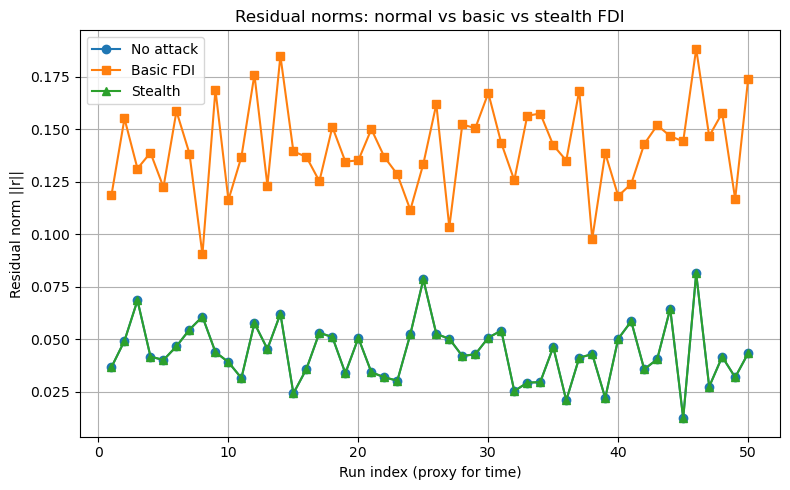

In [15]:
# 6.1 Residual norms over repeated runs

n_runs = 50
sigma = 0.02
attacked_indices = np.arange(H.shape[0])

resid_norms_no = []
resid_norms_basic = []
resid_norms_stealth = []

for k in range(n_runs):
    # Fresh noisy measurements each run
    z_no_k = simulate_measurements(H, x_true, sigma, rng)
    x_hat_no_k, _ = wls_estimate(H, z_no_k, sigma)
    r_no_k = compute_residuals(H, z_no_k, x_hat_no_k)

    z_basic_k = basic_FDIA(z_no_k, attacked_indices, shift=0.1)
    x_hat_basic_k, _ = wls_estimate(H, z_basic_k, sigma)
    r_basic_k = compute_residuals(H, z_basic_k, x_hat_basic_k)

    a_liu_k = stealth_FDIA(H, attacked_indices, alpha=0.05, rng=rng)
    z_stealth_k = z_no_k + a_liu_k
    x_hat_stealth_k, _ = wls_estimate(H, z_stealth_k, sigma)
    r_stealth_k = compute_residuals(H, z_stealth_k, x_hat_stealth_k)

    resid_norms_no.append(np.linalg.norm(r_no_k))
    resid_norms_basic.append(np.linalg.norm(r_basic_k))
    resid_norms_stealth.append(np.linalg.norm(r_stealth_k))

runs = np.arange(1, n_runs + 1)

plt.figure(figsize=(8, 5))
plt.plot(runs, resid_norms_no, marker="o", label="No attack")
plt.plot(runs, resid_norms_basic, marker="s", label="Basic FDI")
plt.plot(runs, resid_norms_stealth, marker="^", label="Stealth")
plt.xlabel("Run index (proxy for time)")
plt.ylabel("Residual norm ||r||")
plt.title("Residual norms: normal vs basic vs stealth FDI")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 - New Plot 2 – State error vs attack magnitude

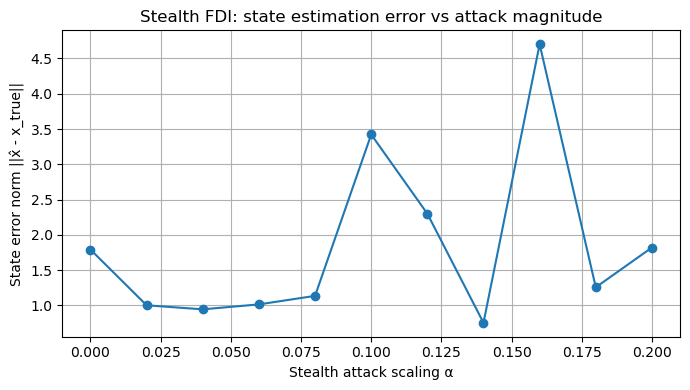

Residual norms for stealth FDI across α (should be ~constant):
[np.float64(0.03487441445778478), np.float64(0.03487441445759085), np.float64(0.03487441445758631), np.float64(0.03487441445762683), np.float64(0.03487441445761263), np.float64(0.03487441445712598), np.float64(0.034874414457750046), np.float64(0.03487441445741452), np.float64(0.03487441445643183), np.float64(0.03487441445752825), np.float64(0.03487441445798231)]
min = 0.03487441445643183 max = 0.03487441445798231


In [37]:
# Stealth FDI: state error vs attack magnitude (residual ~ constant)

attack_magnitudes = np.linspace(0.0, 0.2, 11)

error_norms_stealth = []

# Fix one noisy baseline and one stealth direction
z_no_base = simulate_measurements(H, x_true, sigma, rng)

n = H.shape[1]
c_dir = rng.standard_normal(n)
c_dir = c_dir / np.linalg.norm(c_dir)
a_base = H @ c_dir   # base stealth attack direction in measurement space

for alpha in attack_magnitudes:
    z_stealth_alpha = z_no_base + alpha * a_base

    x_hat_stealth_alpha, _ = wls_estimate(H, z_stealth_alpha, sigma)
    error_norms_stealth.append(np.linalg.norm(x_hat_stealth_alpha - x_true))

plt.figure(figsize=(7, 4))
plt.plot(attack_magnitudes, error_norms_stealth, marker="o")
plt.xlabel("Stealth attack scaling α")
plt.ylabel("State error norm ||x̂ - x_true||")
plt.title("Stealth FDI: state estimation error vs attack magnitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# Optional numeric check on residuals (kept out of the plot)
resid_norms_stealth = []
for alpha in attack_magnitudes:
    z_stealth_alpha = z_no_base + alpha * a_base
    x_hat_stealth_alpha, _ = wls_estimate(H, z_stealth_alpha, sigma)
    r_stealth_alpha = compute_residuals(H, z_stealth_alpha, x_hat_stealth_alpha)
    resid_norms_stealth.append(np.linalg.norm(r_stealth_alpha))

print("Residual norms for stealth FDI across α (should be ~constant):")
print(resid_norms_stealth)
print("min =", min(resid_norms_stealth), "max =", max(resid_norms_stealth))


In [21]:
print(resid_norms_stealth)
print("Min:", min(resid_norms_stealth))
print("Max:", max(resid_norms_stealth))
print("Range:", max(resid_norms_stealth)-min(resid_norms_stealth))

[np.float64(0.03418432835382141), np.float64(0.03418432835391112), np.float64(0.03418432835387554), np.float64(0.03418432835384528), np.float64(0.034184328353820445), np.float64(0.034184328353898556), np.float64(0.0341843283536667), np.float64(0.034184328353813714), np.float64(0.034184328353915445), np.float64(0.03418432835381997), np.float64(0.03418432835382798)]
Min: 0.0341843283536667
Max: 0.034184328353915445
Range: 2.487454686672663e-13


### 7 - Probabilistic state estimation (Kalman-style update)

In [14]:
def kalman_update(x_prior, P_prior, H, z, R, Q=None):
    """
    Single Kalman-filter update for static DC model:
        x_k = x_{k-1}
        z_k = H x_k + v_k

    Q: process noise covariance (small value to keep filter 'soft').
    """
    n = len(x_prior)
    if Q is None:
        Q = 1e-6 * np.eye(n)

    # Prediction (static state, so x_pred = x_prior)
    x_pred = x_prior
    P_pred = P_prior + Q

    # Innovation
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    y = z - H @ x_pred

    # Update
    x_post = x_pred + K @ y
    P_post = (np.eye(n) - K @ H) @ P_pred

    return x_post, P_post


# Build measurement covariance once
R_kf = (sigma ** 2) * np.eye(H.shape[0])

# Vague prior
n = len(x_true)
x_prior = np.zeros(n)
P_prior = 10.0 * np.eye(n)

# Compare no-attack vs stealth for WLS and Kalman
x_hat_wls_no, _ = wls_estimate(H, z_no, sigma)
x_hat_kf_no, P_post_no = kalman_update(x_prior, P_prior, H, z_no, R_kf)

x_hat_wls_stealth, _ = wls_estimate(H, z_stealth, sigma)
x_hat_kf_stealth, P_post_stealth = kalman_update(x_prior, P_prior, H, z_stealth, R_kf)

print("No attack:")
print("  ||x_wls - x_true|| =", np.linalg.norm(x_hat_wls_no - x_true))
print("  ||x_kf  - x_true|| =", np.linalg.norm(x_hat_kf_no  - x_true))

print("\nStealth attack:")
print("  ||x_wls - x_true|| =", np.linalg.norm(x_hat_wls_stealth - x_true))
print("  ||x_kf  - x_true|| =", np.linalg.norm(x_hat_kf_stealth  - x_true))


No attack:
  ||x_wls - x_true|| = 1.8246764137709628
  ||x_kf  - x_true|| = 1.6638170761367637

Stealth attack:
  ||x_wls - x_true|| = 1.5301104468826208
  ||x_kf  - x_true|| = 1.657070190064937


The system operator sees no anomaly in the residual, but the estimated state is corrupted.
I.e. stealth FDIAs can arbitrarily change the estimated system state while keeping the classic residual based detector blind. Motivating the need for ML-based, temporal, or hybrid anomaly detection methods. 